In [ ]:
from google.colab import files
files.upload()

{}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d rumiyyaalili/breast-cancer-dataset-merged

Dataset URL: https://www.kaggle.com/datasets/rumiyyaalili/breast-cancer-dataset-merged
License(s): unknown


In [ ]:
!unzip -qq breast-cancer-dataset-merged

In [ ]:
import os
import random
import numpy as np
from PIL import Image
from tqdm import tqdm
import torch
import torchvision
import torchvision.transforms as transforms
from torch.nn.functional import adaptive_avg_pool2d
from scipy import linalg

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained InceptionV3 model (we use up to pool3 layer)
inception = torchvision.models.inception_v3(pretrained=True, transform_input=False)
inception.fc = torch.nn.Identity()  # remove final classification layer
inception.eval().to(device)

# Define transform
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # Convert grayscale to 3 channels
    transforms.Resize(299),
    transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def get_activations(image_paths, model, batch_size=32):
    model.eval()
    act_list = []

    for i in tqdm(range(0, len(image_paths), batch_size)):
        batch_paths = image_paths[i:i+batch_size]
        batch = []

        for path in batch_paths:
            img = Image.open(path)  # No need to convert to grayscale here
            img = transform(img)  # Apply transformation (including grayscale to 3 channels)
            batch.append(img)

        batch = torch.stack(batch).to(device)

        with torch.no_grad():
            preds = model(batch)

            # Check if preds is 2D or 4D
            if preds.dim() == 4:  # (N, 2048, 1, 1)
                # If preds shape is (N, 2048, 1, 1), no need for adaptive_avg_pool2d
                if preds.shape[2] != 1 or preds.shape[3] != 1:
                    preds = adaptive_avg_pool2d(preds, output_size=(1, 1))
                preds = preds.squeeze(-1).squeeze(-1)
            elif preds.dim() == 2:  # (N, 2048)
                # If preds is already 2D, no need for additional processing
                pass
            else:
                raise ValueError("Unexpected output shape from InceptionV3 model")

            act_list.append(preds.cpu().numpy())

    activations = np.concatenate(act_list, axis=0)
    return activations

def calculate_fid(act1, act2):
    mu1, sigma1 = act1.mean(axis=0), np.cov(act1, rowvar=False)
    mu2, sigma2 = act2.mean(axis=0), np.cov(act2, rowvar=False)

    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)

    # Handle imaginary numbers from sqrtm
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)
    return fid

# Example usage
if __name__ == "__main__":
    # Paths to image folders
    real_folder = "/content/InBreast_Aligned_Images"
    gen_folder = "/content/drive/MyDrive/GAN_TF_checkpoints/generated_images"

    real_paths = [os.path.join(real_folder, f) for f in os.listdir(real_folder) if f.endswith(('.jpeg', '.png'))]
    gen_paths = [os.path.join(gen_folder, f) for f in os.listdir(gen_folder) if f.endswith(('.jpg', '.png'))]

    # Ensure equal number of real and generated images for comparison
    min_len = min(len(real_paths), len(gen_paths))  # Use smaller of both sets (58k for real)
    real_paths = real_paths[:min_len]

    # Sample equal number of generated images as real images
    random.seed(42)  # for reproducibility
    gen_paths = random.sample(gen_paths, len(real_paths))

    print(f"Comparing {len(real_paths)} real images with {len(gen_paths)} generated images...")

    # Get activations
    act_real = get_activations(real_paths, inception)
    act_gen = get_activations(gen_paths, inception)

    # Calculate FID
    fid_value = calculate_fid(act_real, act_gen)
    print(f"FID Score: {fid_value:.4f}")

Comparing 54916 real images with 54916 generated images...


100%|██████████| 1717/1717 [9:43:25<00:00, 20.39s/it]


FID Score: 48.3434


In [ ]:
import os
import random
import numpy as np
import cv2
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim

# Paths to image folders
real_folder = "/content/InBreast_Aligned_Images"
gen_folder = "/content/drive/MyDrive/GAN_TF_checkpoints/generated_images"

# Gather paths to images
real_paths = [os.path.join(real_folder, f) for f in os.listdir(real_folder) if f.endswith(('.jpeg', '.png'))]
gen_paths = [os.path.join(gen_folder, f) for f in os.listdir(gen_folder) if f.endswith(('.jpg', '.png'))]

# Match the number of images
min_len = min(len(real_paths), len(gen_paths))
real_paths = real_paths[:min_len]
random.seed(42)
gen_paths = random.sample(gen_paths, min_len)

print(f"Comparing {len(real_paths)} real and {len(gen_paths)} generated images...")

# Function to compute SSIM
def compute_ssim(real_paths, gen_paths):
    scores = []

    for real_path, gen_path in tqdm(zip(real_paths, gen_paths), total=len(real_paths)):
        # Read both images in grayscale
        real_img = cv2.imread(real_path, cv2.IMREAD_GRAYSCALE)
        gen_img = cv2.imread(gen_path, cv2.IMREAD_GRAYSCALE)

        if real_img is None or gen_img is None:
            continue

        # Resize generated image to match real if needed
        if real_img.shape != gen_img.shape:
            gen_img = cv2.resize(gen_img, (real_img.shape[1], real_img.shape[0]))

        # Compute SSIM
        score, _ = ssim(real_img, gen_img, full=True)
        scores.append(score)

    return np.mean(scores)

# Compute and print SSIM
ssim_score = compute_ssim(real_paths, gen_paths)
print(f"\nMean SSIM Score: {ssim_score:.4f}")

Comparing 54916 real and 54916 generated images...


100%|██████████| 54916/54916 [11:57<00:00, 76.52it/s]


Mean SSIM Score: 0.5362


In [ ]:
!pip install bm3d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 862.0/862.0 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 90.9 MB/s eta 0:00:00


Mounted at /content/drive
Denoised and saved: /content/drive/MyDrive/GAN_TF_checkpoints/bm3d_denoised_images/Copy of image_60000.png
Denoised and saved: /content/drive/MyDrive/GAN_TF_checkpoints/bm3d_denoised_images/Copy of image_59997.png
Denoised and saved: /content/drive/MyDrive/GAN_TF_checkpoints/bm3d_denoised_images/Copy of image_59992.png
Denoised and saved: /content/drive/MyDrive/GAN_TF_checkpoints/bm3d_denoised_images/Copy of image_59979.png
Denoised and saved: /content/drive/MyDrive/GAN_TF_checkpoints/bm3d_denoised_images/Copy of image_59977.png
Denoised and saved: /content/drive/MyDrive/GAN_TF_checkpoints/bm3d_denoised_images/Copy of image_59975.png
Denoised and saved: /content/drive/MyDrive/GAN_TF_checkpoints/bm3d_denoised_images/Copy of image_59974.png
Denoised and saved: /content/drive/MyDrive/GAN_TF_checkpoints/bm3d_denoised_images/Copy of image_59968.png
Denoised and saved: /content/drive/MyDrive/GAN_TF_checkpoints/bm3d_denoised_images/Copy of image_59967.png
Denoised an

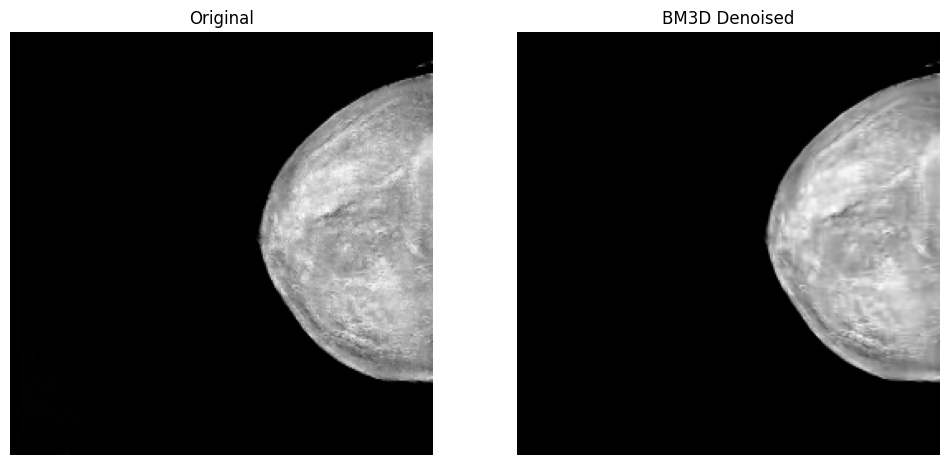

In [ ]:
import os
import numpy as np
from PIL import Image
from bm3d import bm3d
from google.colab import drive
import matplotlib.pyplot as plt

# Mount Google Drive
drive.mount('/content/drive')

# Define paths
input_folder = "/content/drive/MyDrive/new_from_generated"
output_folder = "/content/drive/MyDrive/GAN_TF_checkpoints/bm3d_denoised_images"

# Create the output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Set BM3D noise level (sigma_psd)
sigma_value = 7.0  # Try values from 5.0 to 15.0 depending on noise

# Get list of image files (adjust extensions if needed)
image_files = [f for f in os.listdir(input_folder) if f.endswith(('.png', '.jpg', '.jpeg'))]

# Apply BM3D to each image
for fname in image_files:
    input_path = os.path.join(input_folder, fname)
    output_path = os.path.join(output_folder, fname)

    # Load and convert image to grayscale
    img = Image.open(input_path).convert('L')
    img_np = np.array(img)

    # Apply BM3D denoising
    denoised = bm3d(img_np, sigma_psd=sigma_value)

    # Convert to uint8 for saving
    denoised_uint8 = np.clip(denoised, 0, 255).astype(np.uint8)
    denoised_img = Image.fromarray(denoised_uint8)

    # Save denoised image
    denoised_img.save(output_path)

    print(f"Denoised and saved: {output_path}")

# Optional: Visualize one result
sample_image = image_files[0]
orig = np.array(Image.open(os.path.join(input_folder, sample_image)).convert('L'))
denoised = np.array(Image.open(os.path.join(output_folder, sample_image)))

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(orig, cmap='gray')
ax[0].set_title("Original")
ax[0].axis('off')

ax[1].imshow(denoised, cmap='gray')
ax[1].set_title("BM3D Denoised")
ax[1].axis('off')

plt.show()

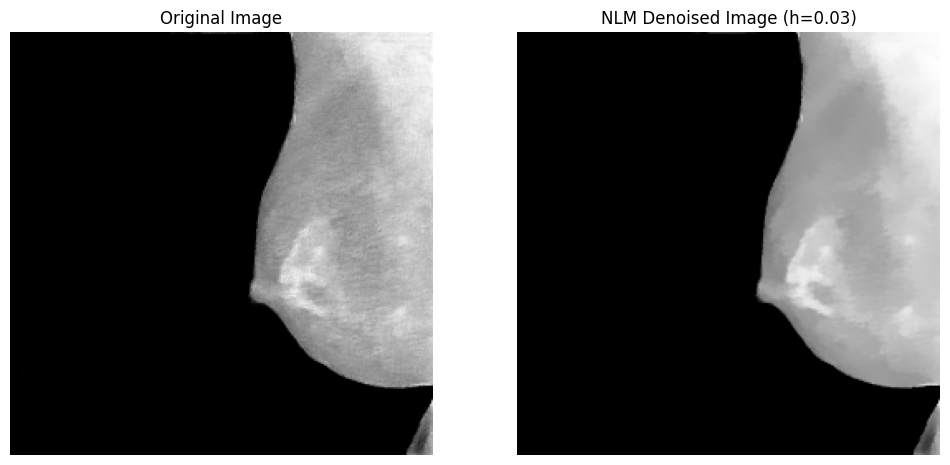

In [ ]:
#INDIVIDUAL
from skimage import restoration
import matplotlib.pyplot as plt
from skimage import io, img_as_float
import numpy as np

# Load image (already grayscale)
image_path = "/content/drive/MyDrive/GAN_TF_checkpoints/generated_images/image_59992.png"
img = io.imread(image_path)

# Convert image to float and normalize to [0, 1]
img_float = img_as_float(img)  # uint8 → float64 in [0.0, 1.0]

# Set filter strength (h)
h_value = 0.03  # try 0.4, 0.8, 1.2, etc.

# Apply NLM denoising
denoised_img_nlm = restoration.denoise_nl_means(
    img_float,
    h=h_value,
    patch_size=2,
    patch_distance=6,
    fast_mode=True
)

# Plot the original and denoised images
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img_float, cmap='gray')
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(denoised_img_nlm, cmap='gray')
ax[1].set_title(f"NLM Denoised Image (h={h_value})")
ax[1].axis('off')

plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Denoised and saved: /content/drive/MyDrive/GAN_TF_checkpoints/nlm_denoised_images/Copy of image_60000.png
Denoised and saved: /content/drive/MyDrive/GAN_TF_checkpoints/nlm_denoised_images/Copy of image_59997.png
Denoised and saved: /content/drive/MyDrive/GAN_TF_checkpoints/nlm_denoised_images/Copy of image_59992.png
Denoised and saved: /content/drive/MyDrive/GAN_TF_checkpoints/nlm_denoised_images/Copy of image_59979.png
Denoised and saved: /content/drive/MyDrive/GAN_TF_checkpoints/nlm_denoised_images/Copy of image_59977.png
Denoised and saved: /content/drive/MyDrive/GAN_TF_checkpoints/nlm_denoised_images/Copy of image_59975.png
Denoised and saved: /content/drive/MyDrive/GAN_TF_checkpoints/nlm_denoised_images/Copy of image_59974.png
Denoised and saved: /content/drive/MyDrive/GAN_TF_checkpoints/nlm_denoised_images/Copy of image_59968.png
Denoised and saved: /co

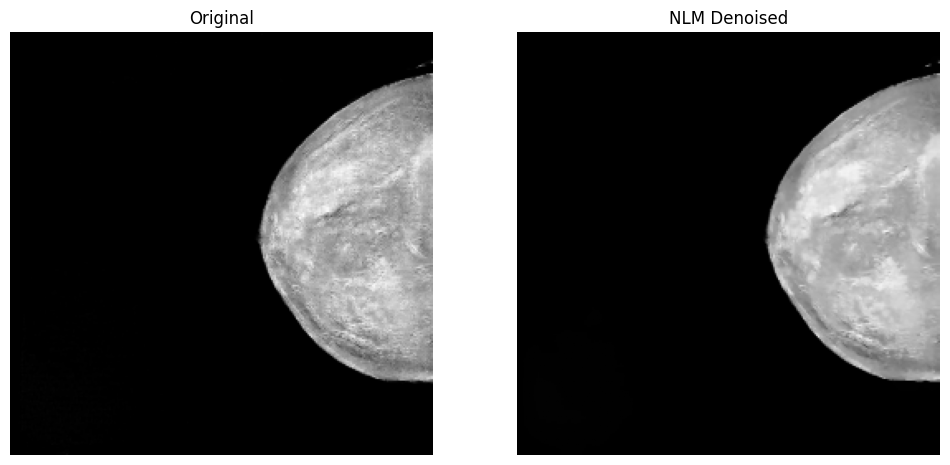

In [ ]:
#BATCH
import os
import numpy as np
from skimage import io, img_as_float, img_as_ubyte, restoration
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Input and output folders
input_folder = "/content/drive/MyDrive/new_from_generated"
output_folder = "/content/drive/MyDrive/GAN_TF_checkpoints/nlm_denoised_images"

# Create output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# NLM filter parameters
h_value = 0.03  # Try changing this (e.g., 0.4, 0.8)
patch_size = 2
patch_distance = 6

# Get list of image files
image_files = [f for f in os.listdir(input_folder) if f.endswith(('.png', '.jpg', '.jpeg'))]

# Process each image
for fname in image_files:
    input_path = os.path.join(input_folder, fname)
    output_path = os.path.join(output_folder, fname)

    # Load image and convert to float
    img = io.imread(input_path)
    img_float = img_as_float(img)

    # Apply NLM denoising
    denoised = restoration.denoise_nl_means(
        img_float,
        h=h_value,
        patch_size=patch_size,
        patch_distance=patch_distance,
        fast_mode=True
    )

    # Convert back to 8-bit and save
    denoised_uint8 = img_as_ubyte(denoised)
    Image.fromarray(denoised_uint8).save(output_path)

    print(f"Denoised and saved: {output_path}")

# Optional visualization
sample_image = image_files[0]
original = img_as_float(io.imread(os.path.join(input_folder, sample_image)))
denoised = img_as_float(io.imread(os.path.join(output_folder, sample_image)))

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(original, cmap='gray')
ax[0].set_title("Original")
ax[0].axis('off')

ax[1].imshow(denoised, cmap='gray')
ax[1].set_title("NLM Denoised")
ax[1].axis('off')

plt.show()

In [ ]:
#MPV and MPVD calculations
import os
import numpy as np
from skimage.io import imread
from skimage import img_as_float

def calculate_mpv_mpvd(folder_path):
    mpvs = []

    # Get sorted list of image files (adjust extensions as needed)
    image_files = sorted([
        f for f in os.listdir(folder_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

    if not image_files:
        print("No images found.")
        return None, None

    for file in image_files:
        img = imread(os.path.join(folder_path, file))
        img_float = img_as_float(img)  # normalize to [0, 1]
        mpv = np.mean(img_float)
        mpvs.append(mpv)

    # Calculate Global MPV
    global_mpv = np.mean(mpvs)

    # Calculate Global MPVD
    mpv_diffs = [abs(mpvs[i+1] - mpvs[i]) for i in range(len(mpvs) - 1)]
    global_mpvd = np.mean(mpv_diffs) if mpv_diffs else 0

    return global_mpv, global_mpvd

folder_bm3d = "/content/drive/MyDrive/GAN_TF_checkpoints/bm3d_denoised_images"
folder_nlm = "/content/drive/MyDrive/GAN_TF_checkpoints/nlm_denoised_images"
folder_generated = "/content/drive/MyDrive/new_from_generated"
folder_real = "/content/drive/MyDrive/InBreast_Aligned_Images"

mpv_bm3d, mpvd_bm3d = calculate_mpv_mpvd(folder_bm3d)
mpv_nlm, mpvd_nlm = calculate_mpv_mpvd(folder_nlm)
mpv_gen, mpvd_gen = calculate_mpv_mpvd(folder_generated)
mpv_real, mpvd_real = calculate_mpv_mpvd(folder_real)

print(f"BM3D - Global MPV: {mpv_bm3d:.4f}, Global MPVD: {mpvd_bm3d:.4f}")
print(f"NLM  - Global MPV: {mpv_nlm:.4f}, Global MPVD: {mpvd_nlm:.4f}")
print(f"Generated - Global MPV: {mpv_gen:.4f}, Global MPVD: {mpvd_gen:.4f}")

BM3D - Global MPV: 0.2282, Global MPVD: 0.0632
NLM  - Global MPV: 0.2290, Global MPVD: 0.0634
Generated - Global MPV: 0.2291, Global MPVD: 0.0634


In [ ]:
print(f"Real - Global MPV: {mpv_real:.4f}, Global MPVD: {mpvd_real:.4f}")

Real - Global MPV: 0.1391, Global MPVD: 0.0434


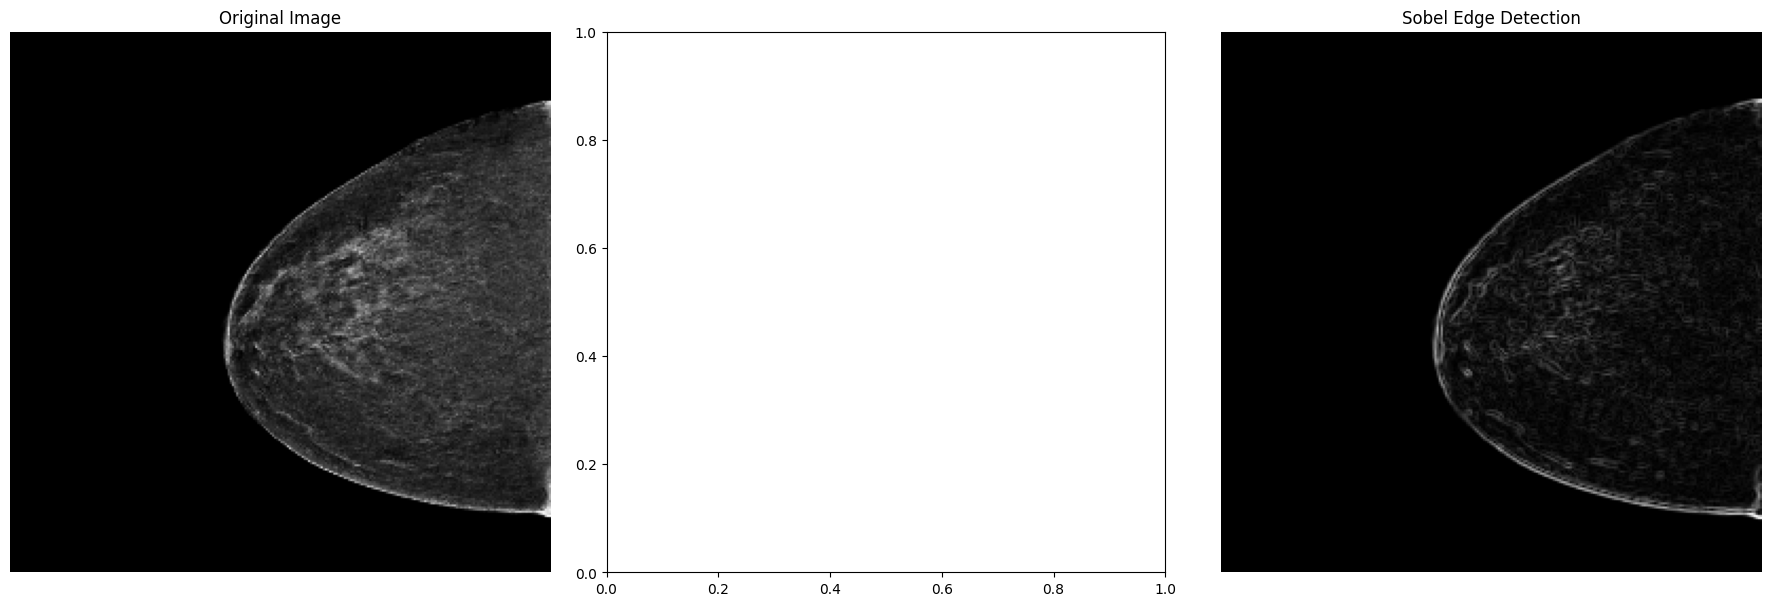

In [ ]:
#EDGE DETECTION: SOBEL INDIVIDUAL
import matplotlib.pyplot as plt
from skimage import io, feature, filters, img_as_float
import numpy as np

# Load grayscale image
image_path = "/content/drive/MyDrive/GAN_TF_checkpoints/generated_images/image_59998.png"
img = io.imread(image_path)

# Ensure image is float and normalized
img = img_as_float(img)

# --- Apply Sobel Edge Detection ---
edges_sobel = filters.sobel(img)

# --- Plotting ---
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(img, cmap='gray')
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[2].imshow(edges_sobel, cmap='gray')
ax[2].set_title("Sobel Edge Detection")
ax[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# EDGE DETECTION IN BATCH FOR GENERATED IMAGES
import os
import numpy as np
from skimage import io, filters, img_as_float, img_as_ubyte
from skimage.util import img_as_ubyte
from PIL import Image
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')
# Define input and output folders
input_folder = "/content/drive/MyDrive/GAN_TF_checkpoints/generated_images"
output_folder = "/content/drive/MyDrive/GAN_TF_checkpoints/sobel_edges"

# Create output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Loop through all images in the folder
for filename in os.listdir(input_folder):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp')):
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)

        # Read and normalize image
        img = io.imread(input_path)
        img = img_as_float(img)  # Normalize to [0, 1]

        # Apply Sobel edge detection
        edges_sobel = filters.sobel(img)

        # Convert to 8-bit image for saving
        edge_uint8 = img_as_ubyte(edges_sobel)

        # Save the result
        Image.fromarray(edge_uint8).save(output_path)

print("All images processed and saved with Sobel edges.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All images processed and saved with Sobel edges.


In [ ]:
# EDGE DETECTION IN BATCH FOR REAL IMAGES
import os
import numpy as np
from skimage import io, filters, img_as_float, img_as_ubyte
from skimage.util import img_as_ubyte
from PIL import Image
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define input and output folders
input_folder = "/content/drive/MyDrive/InBreast_Aligned_Images"
output_folder = "/content/drive/MyDrive/sobel_edges_real"

# Create output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Loop through all images in the folder
for filename in os.listdir(input_folder):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp')):
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)

        # Read and normalize image
        img = io.imread(input_path)
        img = img_as_float(img)  # Normalize to [0, 1]

        # Apply Sobel edge detection
        edges_sobel = filters.sobel(img)

        # Convert to 8-bit image for saving
        edge_uint8 = img_as_ubyte(edges_sobel)

        # Save the result
        Image.fromarray(edge_uint8).save(output_path)

print("All images processed and saved with Sobel edges.")

Mounted at /content/drive
All images processed and saved with Sobel edges.


In [ ]:
# SSIM CALCULATION AFTER THE SOBEL EDGE DETECTION FOR GENERATED IMAGES
import os
import random
import numpy as np
import cv2
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Paths to image folders
real_folder = "/content/drive/MyDrive/sobel_edges_real"
gen_folder = "/content/drive/MyDrive/GAN_TF_checkpoints/sobel_edges"

# Gather paths to images
real_paths = [os.path.join(real_folder, f) for f in os.listdir(real_folder) if f.endswith(('.jpeg', '.png'))]
gen_paths = [os.path.join(gen_folder, f) for f in os.listdir(gen_folder) if f.endswith(('.jpg', '.png'))]

# Match the number of images
min_len = min(len(real_paths), len(gen_paths))
real_paths = real_paths[:min_len]
random.seed(42)
gen_paths = random.sample(gen_paths, min_len)

print(f"Comparing {len(real_paths)} real and {len(gen_paths)} generated images...")

# Function to compute SSIM
def compute_ssim(real_paths, gen_paths):
    scores = []

    for real_path, gen_path in tqdm(zip(real_paths, gen_paths), total=len(real_paths)):
        # Read both images in grayscale
        real_img = cv2.imread(real_path, cv2.IMREAD_GRAYSCALE)
        gen_img = cv2.imread(gen_path, cv2.IMREAD_GRAYSCALE)

        if real_img is None or gen_img is None:
            continue

        # Resize generated image to match real if needed
        if real_img.shape != gen_img.shape:
            gen_img = cv2.resize(gen_img, (real_img.shape[1], real_img.shape[0]))

        # Compute SSIM
        score, _ = ssim(real_img, gen_img, full=True)
        scores.append(score)

    return np.mean(scores)

# Compute and print SSIM
ssim_score = compute_ssim(real_paths, gen_paths)
print(f"\nMean SSIM Score: {ssim_score:.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Comparing 19720 real and 19720 generated images...


100%|██████████| 19720/19720 [1:39:00<00:00,  3.32it/s]


Mean SSIM Score: 0.6048


In [ ]:
#GLCM FOR TEXTURE ANALYSIS: INDIVIDUAL
from skimage.feature import graycomatrix, graycoprops
from skimage import io, img_as_ubyte
import numpy as np

# Load and convert image to 8-bit
image = img_as_ubyte(io.imread("/content/drive/MyDrive/GAN_TF_checkpoints/generated_images/image_59998.png"))  # Must be uint8

# Compute GLCM
glcm = graycomatrix(image, distances=[1], angles=[0], symmetric=True, normed=True)

# Extract features
contrast = graycoprops(glcm, 'contrast')[0, 0]
correlation = graycoprops(glcm, 'correlation')[0, 0]
energy = graycoprops(glcm, 'energy')[0, 0]
homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]

print(f"Contrast: {contrast}, Correlation: {correlation}, Energy: {energy}, Homogeneity: {homogeneity}")

Contrast: 122.74975490196078, Correlation: 0.9255650745424296, Energy: 0.6485496135774973, Homogeneity: 0.681211149198715


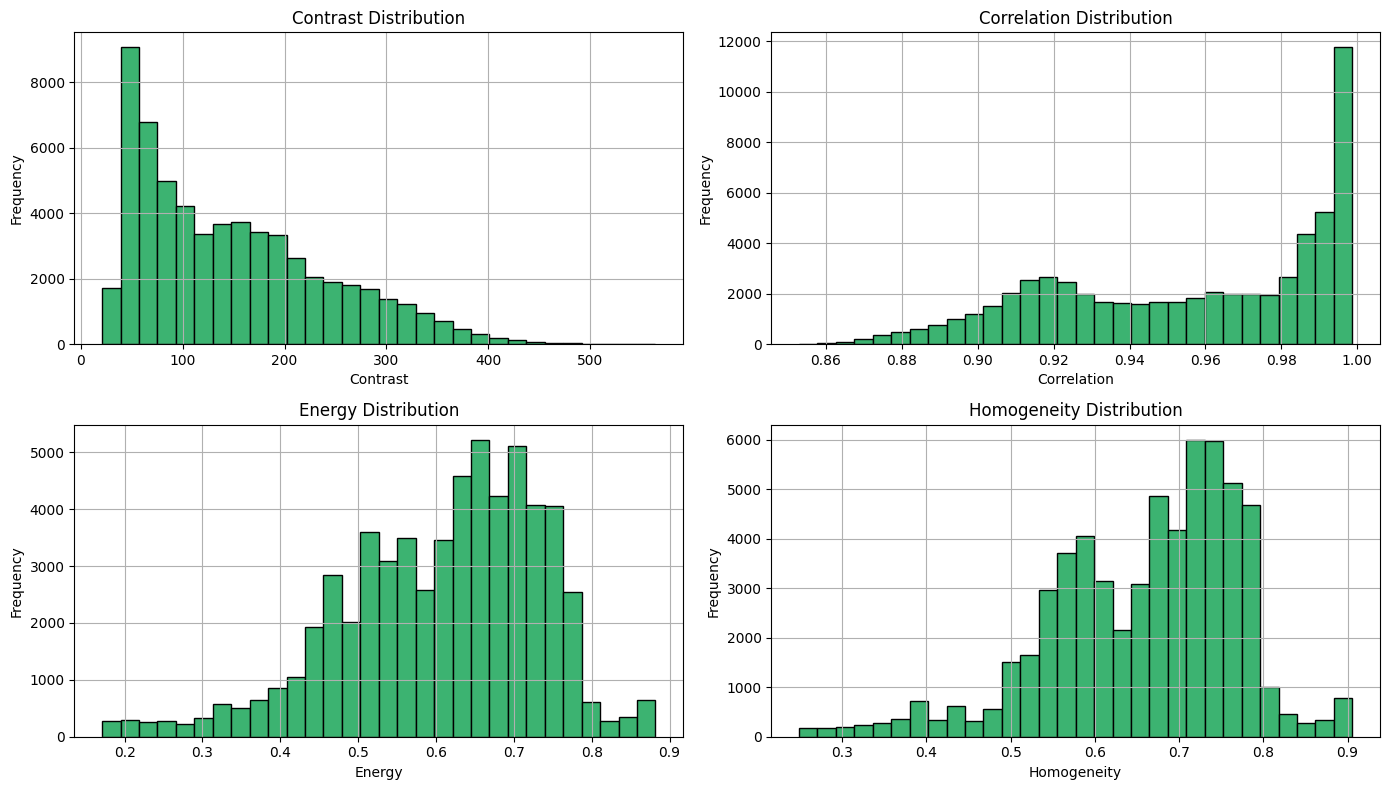

In [ ]:
# FOR GENERATED IMAGES
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops
from skimage import io, img_as_ubyte

# --- CONFIGURATION ---
folder_path = "/content/drive/MyDrive/GAN_TF_checkpoints/generated_images"  # Your folder
image_extensions = ('.png', '.jpg', '.jpeg')

# Lists to collect feature values
contrast_vals = []
correlation_vals = []
energy_vals = []
homogeneity_vals = []

# --- PROCESSING LOOP ---
for filename in os.listdir(folder_path):
    if filename.lower().endswith(image_extensions):
        image_path = os.path.join(folder_path, filename)
        try:
            image = img_as_ubyte(io.imread(image_path, as_gray=True))  # Ensure grayscale
            glcm = graycomatrix(image, distances=[1], angles=[0], symmetric=True, normed=True)

            contrast_vals.append(graycoprops(glcm, 'contrast')[0, 0])
            correlation_vals.append(graycoprops(glcm, 'correlation')[0, 0])
            energy_vals.append(graycoprops(glcm, 'energy')[0, 0])
            homogeneity_vals.append(graycoprops(glcm, 'homogeneity')[0, 0])

        except Exception as e:
            print(f"Failed to process {filename}: {e}")

# --- PLOT DISTRIBUTIONS ---
features = {
    'Contrast': contrast_vals,
    'Correlation': correlation_vals,
    'Energy': energy_vals,
    'Homogeneity': homogeneity_vals
}

plt.figure(figsize=(14, 8))
for i, (name, values) in enumerate(features.items(), 1):
    plt.subplot(2, 2, i)
    plt.hist(values, bins=30, color='mediumseagreen', edgecolor='black')
    plt.title(f'{name} Distribution')
    plt.xlabel(name)
    plt.ylabel('Frequency')
    plt.grid(True)

plt.tight_layout()
plt.show()

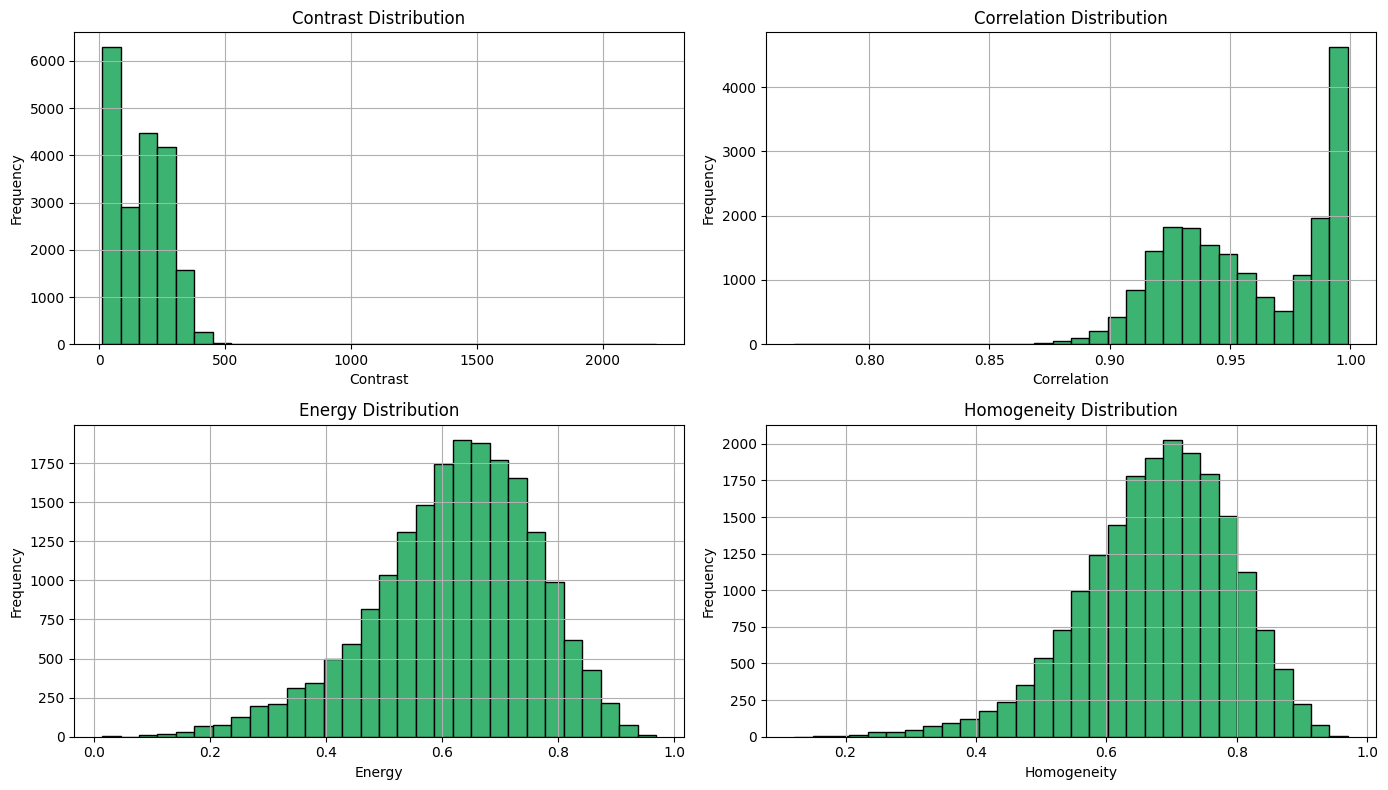

In [ ]:
# FOR REAL IMAGES
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops
from skimage import io, img_as_ubyte

# --- CONFIGURATION ---
folder_path = "/content/drive/MyDrive/InBreast_Aligned_Images"  # Your folder
image_extensions = ('.png', '.jpg', '.jpeg')

# Lists to collect feature values
contrast_vals = []
correlation_vals = []
energy_vals = []
homogeneity_vals = []

# --- PROCESSING LOOP ---
for filename in os.listdir(folder_path):
    if filename.lower().endswith(image_extensions):
        image_path = os.path.join(folder_path, filename)
        try:
            image = img_as_ubyte(io.imread(image_path, as_gray=True))  # Ensure grayscale
            glcm = graycomatrix(image, distances=[1], angles=[0], symmetric=True, normed=True)

            contrast_vals.append(graycoprops(glcm, 'contrast')[0, 0])
            correlation_vals.append(graycoprops(glcm, 'correlation')[0, 0])
            energy_vals.append(graycoprops(glcm, 'energy')[0, 0])
            homogeneity_vals.append(graycoprops(glcm, 'homogeneity')[0, 0])

        except Exception as e:
            print(f"Failed to process {filename}: {e}")

# --- PLOT DISTRIBUTIONS ---
features = {
    'Contrast': contrast_vals,
    'Correlation': correlation_vals,
    'Energy': energy_vals,
    'Homogeneity': homogeneity_vals
}

plt.figure(figsize=(14, 8))
for i, (name, values) in enumerate(features.items(), 1):
    plt.subplot(2, 2, i)
    plt.hist(values, bins=30, color='mediumseagreen', edgecolor='black')
    plt.title(f'{name} Distribution')
    plt.xlabel(name)
    plt.ylabel('Frequency')
    plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# --- CONFIGURATION ---
real_path = "/content/drive/MyDrive/InBreast_Aligned_Images"
fake_path = "/content/drive/MyDrive/GAN_TF_checkpoints/generated_images"
image_extensions = ('.png', '.jpg', '.jpeg')

# --- REAL FEATURES ---
real_features = {
    'Contrast': [],
    'Correlation': [],
    'Energy': [],
    'Homogeneity': []
}

for filename in os.listdir(real_path):
    if filename.lower().endswith(image_extensions):
        try:
            image = img_as_ubyte(io.imread(os.path.join(real_path, filename), as_gray=True))
            glcm = graycomatrix(image, distances=[1], angles=[0], symmetric=True, normed=True)
            real_features['Contrast'].append(graycoprops(glcm, 'contrast')[0, 0])
            real_features['Correlation'].append(graycoprops(glcm, 'correlation')[0, 0])
            real_features['Energy'].append(graycoprops(glcm, 'energy')[0, 0])
            real_features['Homogeneity'].append(graycoprops(glcm, 'homogeneity')[0, 0])
        except Exception as e:
            print(f"Real image error: {e}")

# --- FAKE FEATURES ---
fake_features = {
    'Contrast': [],
    'Correlation': [],
    'Energy': [],
    'Homogeneity': []
}

for filename in os.listdir(fake_path):
    if filename.lower().endswith(image_extensions):
        try:
            image = img_as_ubyte(io.imread(os.path.join(fake_path, filename), as_gray=True))
            glcm = graycomatrix(image, distances=[1], angles=[0], symmetric=True, normed=True)
            fake_features['Contrast'].append(graycoprops(glcm, 'contrast')[0, 0])
            fake_features['Correlation'].append(graycoprops(glcm, 'correlation')[0, 0])
            fake_features['Energy'].append(graycoprops(glcm, 'energy')[0, 0])
            fake_features['Homogeneity'].append(graycoprops(glcm, 'homogeneity')[0, 0])
        except Exception as e:
            print(f"Fake image error: {e}")

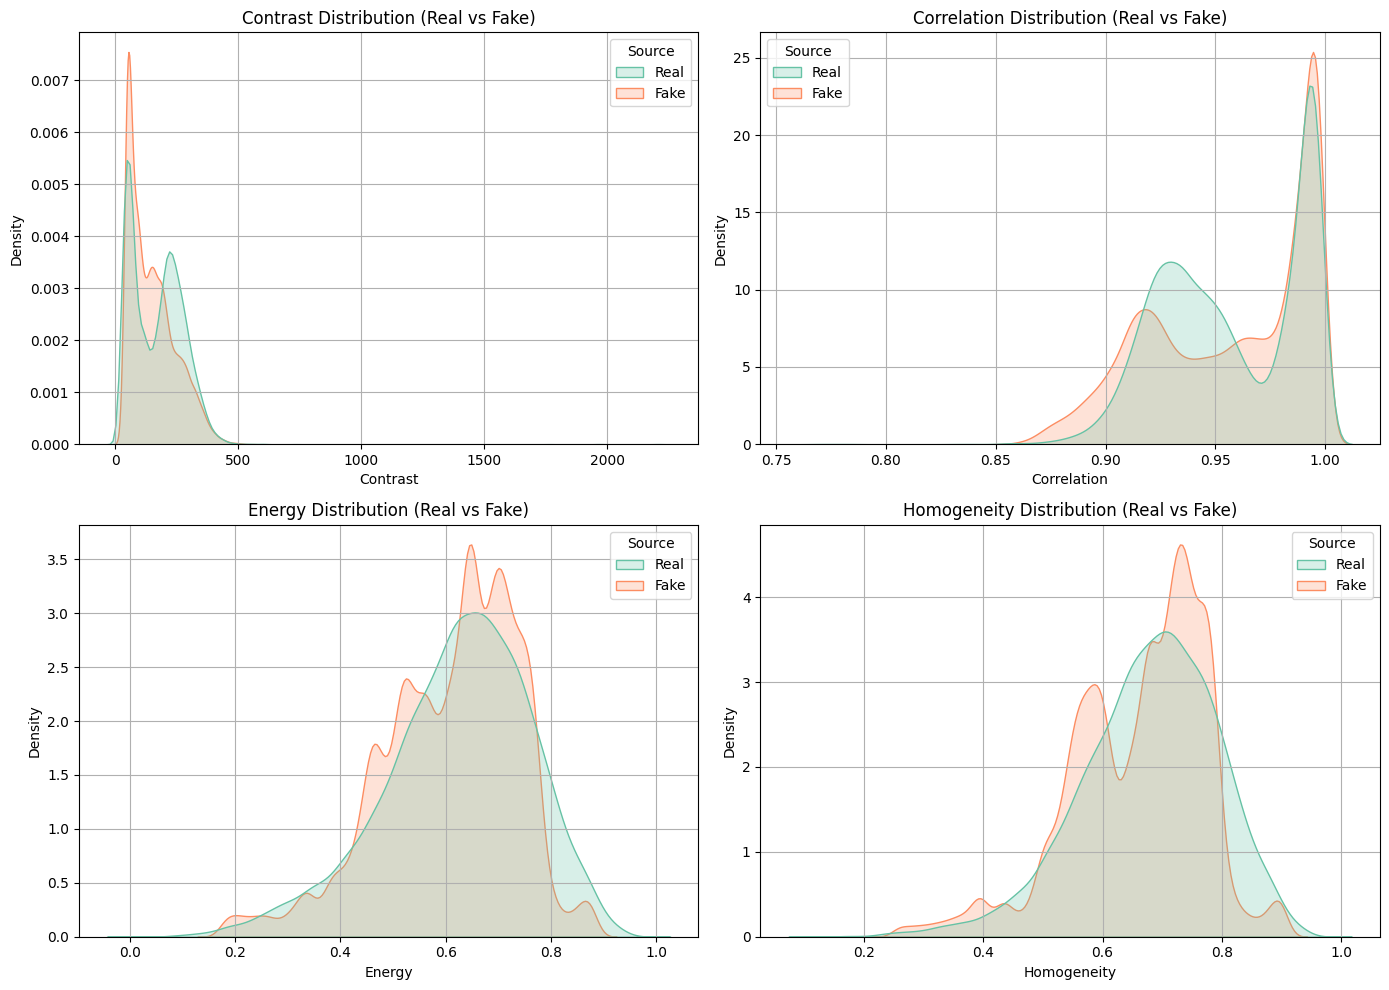

In [ ]:
import seaborn as sns
import pandas as pd

# Combine into DataFrame
combined_data = []
for feature in real_features:
    combined_data.extend([(val, feature, 'Real') for val in real_features[feature]])
    combined_data.extend([(val, feature, 'Fake') for val in fake_features[feature]])

df = pd.DataFrame(combined_data, columns=['Value', 'Feature', 'Source'])

# Plot
plt.figure(figsize=(14, 10))
for i, feature in enumerate(df['Feature'].unique(), 1):
    plt.subplot(2, 2, i)
    sns.kdeplot(data=df[df['Feature'] == feature], x='Value', hue='Source', fill=True, common_norm=False, palette='Set2')
    plt.title(f'{feature} Distribution (Real vs Fake)')
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops
from scipy.ndimage import gaussian_filter
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# === Step 1: Load and preprocess image ===
def load_image(path, size=(256, 256)):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Image not found or unable to load: {path}")
    img = cv2.resize(img, size)
    return img

# === Step 2: Smooth sliding window texture map ===
def compute_texture_map(img, step=8, window_size=32, glcm_prop='contrast', levels=32):
    texture_map = np.zeros(img.shape, dtype=np.float32)
    count_map = np.zeros(img.shape, dtype=np.float32)

    for i in range(0, img.shape[0] - window_size + 1, step):
        for j in range(0, img.shape[1] - window_size + 1, step):
            patch = img[i:i+window_size, j:j+window_size]
            patch_quantized = (patch / (256 / levels)).astype(np.uint8)

            glcm = graycomatrix(patch_quantized, distances=[1], angles=[0], levels=levels, symmetric=True, normed=True)
            value = graycoprops(glcm, glcm_prop)[0, 0]

            texture_map[i:i+window_size, j:j+window_size] += value
            count_map[i:i+window_size, j:j+window_size] += 1

    texture_map /= (count_map + 1e-6)  # Avoid division by zero
    texture_map = gaussian_filter(texture_map, sigma=3)  # smooth the texture map
    return texture_map

# === Step 3: Visualize with transparent heatmap ===
def overlay_heatmap(img, texture_map, alpha=0.5, threshold_percentile=95):
    threshold = np.percentile(texture_map, threshold_percentile)
    heatmap_mask = (texture_map > threshold).astype(np.float32)

    # Normalize for display
    heatmap = cv2.normalize(texture_map, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET).astype(np.float32)

    # Blend only suspicious areas
    img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR).astype(np.float32)
    overlay = img_color.copy()
    mask_indices = heatmap_mask > 0

    # Perform blending on float32 arrays
    overlay[mask_indices] = cv2.addWeighted(
        img_color[mask_indices], 1 - alpha,
        heatmap_colored[mask_indices], alpha,
        0
    )

    # Convert final image back to uint8 for display
    return np.clip(overlay, 0, 255).astype(np.uint8)
# === Step 4: Plotting ===
def analyze_and_plot(path):
    img = load_image(path)
    texture_map = compute_texture_map(img, step=8)
    overlay_img = overlay_heatmap(img, texture_map)

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Image')

    plt.subplot(1, 3, 2)
    plt.imshow(texture_map, cmap='hot')
    plt.title('Smooth Texture Map')

    plt.subplot(1, 3, 3)
    plt.imshow(overlay_img)
    plt.title('Suspicious Areas (Smooth Overlay)')

    plt.tight_layout()
    plt.show()

# === Step 5: Run with your image ===
image_path1 = "/content/drive/MyDrive/GAN_TF_checkpoints/generated_images/image_59995.png"
analyze_and_plot(image_path1)
image_path2 = "/content/drive/MyDrive/GAN_TF_checkpoints/generated_images/image_59994.png"
analyze_and_plot(image_path2)
image_path3 = "/content/drive/MyDrive/GAN_TF_checkpoints/generated_images/image_59998.png"
analyze_and_plot(image_path3)
image_path4 = "/content/drive/MyDrive/GAN_TF_checkpoints/generated_images/image_59980.png"
analyze_and_plot(image_path4)
image_path5 = "/content/drive/MyDrive/GAN_TF_checkpoints/generated_images/image_59972.png"
analyze_and_plot(image_path5)
image_path6 = "/content/drive/MyDrive/GAN_TF_checkpoints/generated_images/image_59964.png"
analyze_and_plot(image_path6)
image_path7 = "/content/drive/MyDrive/GAN_TF_checkpoints/generated_images/image_59928.png"
analyze_and_plot(image_path7)
image_path8 = "/content/drive/MyDrive/GAN_TF_checkpoints/generated_images/image_59902.png"
analyze_and_plot(image_path8)
image_path9 = "/content/drive/MyDrive/GAN_TF_checkpoints/generated_images/image_59877.png"
analyze_and_plot(image_path9)
image_path10 = "/content/drive/MyDrive/GAN_TF_checkpoints/generated_images/image_59823.png"
analyze_and_plot(image_path10)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
!pip uninstall -y scikit-image
!pip install scikit-image==0.19.3

Found existing installation: scikit-image 0.25.2
Uninstalling scikit-image-0.25.2:
  Successfully uninstalled scikit-image-0.25.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 68.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 89.4 MB/s eta 0:00:00
  Created wheel for scikit-image: filename=scikit_image-0.19.3-cp311-cp311-linux_x86_64.whl size=33913463 sha256=be607eba7c8ad8b429276f61244f6430a068654adae54788f75b3a194076cd16
  Stored in directory: /root/.cache/pip/wheels/7b/12/cd/f311cabf9e8708d1e29e9951ee0839fb89b69e1acc60c94927
Successfully built scikit-image


In [ ]:
!pip uninstall -y numpy
!pip install numpy==1.23.5

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 77.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
chex 0.1.89 requires numpy>=1.24.1, but you have numpy 1.23.5 which is incompatible.
pymc 5.21.2 requires numpy>=1.25.0, but you have numpy 1.23.5 which is incompatible.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.23.5 which is incompatible.
xarray 2025.1.2 requires numpy>=1.24, but you have numpy 1.23.5 which is incompatible.
bigframes 1.42.0 requires numpy>=1.24.0, but you have numpy 1.23.5 which is incompatible.
blosc2 3.2.1 requires numpy>=1.26, but you have numpy 1.23.5 which is incompatible.
albumentations 2.0.5 requires numpy>=1.24.4, but you have numpy 1.23.5 which is incompatible.
treescope 0.1.9 requires numpy>

In [ ]:
import os
import numpy as np
from skimage import io, img_as_float
from skimage.metrics import mean_squared_error

generated_folder = "/content/drive/MyDrive/GAN_TF_checkpoints/generated_images"
real_folder = "/content/drive/MyDrive/InBreast_Aligned_Images"
image_extensions = ('.png', '.jpg', '.jpeg')

gen_files = sorted([f for f in os.listdir(generated_folder) if f.lower().endswith(image_extensions)])
real_files = sorted([f for f in os.listdir(real_folder) if f.lower().endswith(image_extensions)])

mse_values = []
paired = list(zip(gen_files, real_files))

for gen_name, real_name in paired:
    gen_path = os.path.join(generated_folder, gen_name)
    real_path = os.path.join(real_folder, real_name)

    try:
        gen_img = img_as_float(io.imread(gen_path, as_gray=True))
        real_img = img_as_float(io.imread(real_path, as_gray=True))

        if gen_img.shape == real_img.shape:
            mse = mean_squared_error(real_img, gen_img)
            mse_values.append(mse)
        else:
            print(f"⚠️ Size mismatch: {gen_name} and {real_name}")
    except Exception as e:
        print(f"❌ Error comparing {gen_name} with {real_name}: {e}")

# Final result
if mse_values:
    print(f"\n✅ Compared {len(mse_values)} image pairs.")
    print(f"📊 Average MSE: {np.mean(mse_values):.6f}")
else:
    print("\n❌ No valid image pairs processed.")


✅ Compared 19720 image pairs.
📊 Average MSE: 0.052092


In [1]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/user_results.csv")
print(df.head())

Mounted at /content/drive
   Correct  Response Time (s)  Changed Mind Count              Name  \
0    False              55.63                   0  Zarifa Jafarzada   
1    False              55.06                   0  Zarifa Jafarzada   
2     True              60.51                   0  Zarifa Jafarzada   
3     True              18.24                   0  Zarifa Jafarzada   
4    False              46.61                   0  Zarifa Jafarzada   

                     Role  
0  Senior medical student  
1  Senior medical student  
2  Senior medical student  
3  Senior medical student  
4  Senior medical student  


In [4]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Load the CSV file
df = pd.read_csv("/content/drive/MyDrive/user_results.csv")
print(df.head())

# Group by User and Role
grouped = df.groupby(['Name', 'Role'])  # Change 'User' if your user identifier column has a different name

# Calculate metrics per user
accuracy_by_user = grouped['Correct'].mean()
min_time_by_user = grouped['Response Time (s)'].min()
max_time_by_user = grouped['Response Time (s)'].max()
avg_time_by_user = grouped['Response Time (s)'].mean()

# Combine into a single DataFrame
user_summary = pd.DataFrame({
    'Accuracy': accuracy_by_user,
    'Min Response Time (s)': min_time_by_user,
    'Max Response Time (s)': max_time_by_user,
    'Avg Response Time (s)': avg_time_by_user
}).reset_index()

# Display results
print("\nPerformance summary by user and role:")
print(user_summary)

# Overall metrics
overall_accuracy = df['Correct'].mean()
overall_time = df['Response Time (s)'].mean()
print(f"\nOverall accuracy: {overall_accuracy:.4f}")
print(f"Overall average decision time: {overall_time:.4f} seconds")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Correct  Response Time (s)  Changed Mind Count              Name  \
0    False              55.63                   0  Zarifa Jafarzada   
1    False              55.06                   0  Zarifa Jafarzada   
2     True              60.51                   0  Zarifa Jafarzada   
3     True              18.24                   0  Zarifa Jafarzada   
4    False              46.61                   0  Zarifa Jafarzada   

                     Role  
0  Senior medical student  
1  Senior medical student  
2  Senior medical student  
3  Senior medical student  
4  Senior medical student  

Performance summary by user and role:
               Name                    Role  Accuracy  Min Response Time (s)  \
0  Heqiqet Veliyeva          Breast Surgeon  0.760000                   3.68   
1  Konul Farhadzada    Radiologist-mammolog  0.827586                   4.03 

In [ ]:
accuracy_by_role = df.groupby('Role')['Correct'].mean()
print("Accuracy by role:\n", accuracy_by_role)

Accuracy by role:
 Role
Breast Surgeon            0.808511
Radiologist-mammolog      0.827586
Senior medical student    0.772727
Name: Correct, dtype: float64


In [ ]:
time_by_role = df.groupby('Role')['Response Time (s)'].mean()
print("Average decision time by role:\n", time_by_role)

Average decision time by role:
 Role
Breast Surgeon            18.661489
Radiologist-mammolog      10.998966
Senior medical student    25.385909
Name: Response Time (s), dtype: float64


In [ ]:
overall_accuracy = df['Correct'].mean()
overall_time = df['Response Time (s)'].mean()
print(f"\nOverall accuracy: {overall_accuracy:.4f}")
print(f"Overall average decision time: {overall_time:.4f} seconds")


Overall accuracy: 0.8061
Overall average decision time: 17.9036 seconds
